# Navier-Stokes equations — implementation notes

The incompressible Navier-Stokes equations form a coupled PDE system:

<img src="../static/1.png" height="120" style="display:block; margin:auto;">

where the stress tensor $\sigma(u, p)$ is:

<img src="../static/2.png" height="60" style="display:block; margin:auto;">

and the strain-rate tensor $\epsilon(u)$ is:

<img src="../static/3.png" height="60" style="display:block; margin:auto;">

## Splitting scheme (IPCS)

Rather than solving the coupled system directly (which has a saddle-point structure), 
we use the incremental pressure correction scheme (IPCS) — a modified Chorin splitting 
method that solves three linear problems per timestep. Full derivation: 
[Dokken (2023)](https://jsdokken.com/dolfinx-tutorial/chapter2/navierstokes.html).

### Step 1 — tentative velocity

<img src="../static/4.png" height="60" style="display:block; margin:auto;">

where:
- $\langle \cdot, \cdot \rangle$ — $L^2$ inner product over $\Omega$, i.e. $\int_\Omega uv \ dx$
- $\langle \cdot, \cdot \rangle_{\partial\Omega}$ — boundary inner product, i.e. $\int_{\partial\Omega} uv \ ds$
- $u^{n+1/2} \approx \frac{u^n + u^*}{2}$ — midpoint approximation
- $u^*$ — tentative velocity using pressure $p^n$ from previous timestep

### Step 2 — pressure correction

With $q$ the pressure test function and $v$ the velocity test function:

<img src="../static/5.png" height="80" style="display:block; margin:auto;">

which gives the variational form:

<img src="../static/6.png" height="80" style="display:block; margin:auto;">

In [3]:
# Channel flow (Poiseyuille flow)

from mpi4py import MPI
from petsc4py import PETSc
import numpy as np
import pyvista as pv

from dolfinx.fem import (
    Constant,
    Function,
    extract_function_spaces,
    functionspace,
    assemble_scalar,
    dirichletbc,
    form,
    locate_dofs_geometrical,
)

from dolfinx.fem.petsc import (
    assemble_matrix,
    assemble_vector,
    apply_lifting,
    create_vector,
    set_bc,
)

from dolfinx.io import VTXWriter
from dolfinx.mesh import create_unit_square
from dolfinx.plot import vtk_mesh
from basix.ufl import element
from ufl import (
    FacetNormal,
    Identity,
    TestFunction,
    TrialFunction,
    div,
    dot,
    ds,
    dx,
    inner,
    lhs,
    nabla_grad,
    rhs,
    sym,
)

mesh = create_unit_square(MPI.COMM_WORLD, 10, 10)
t = 0
T = 10
num_steps = 500
dt = (T - t) / num_steps

v_cg2 = element('Lagrange', mesh.basix_cell(), 2, shape = (mesh.geometry.dim,))
s_cg1 = element('Lagrange', mesh.basix_cell(), 1) 
V = functionspace(mesh, v_cg2)
Q = functionspace(mesh, s_cg1)

u = TrialFunction(V)
v = TestFunction(V)
p = TrialFunction(Q)
q = TestFunction(Q)

def walls(x):
    return np.logical_or( np.isclose(x[1], 0), np.isclose(x[1], 1))

wall_dofs = locate_dofs_geometrical(V, walls)
n_noslip = np.array((0,) * mesh.geometry.dim, dtype = PETSc.ScalarType)
bc_noslipe = dirichletbc(n_noslip, wall_dofs, V)

def inflow(x):
    return np.isclose(x[0],0)

ifnlow_dofs = locate_dofs_geometrical(Q, inflow)
bc_inflows = dirichletbc(PETSc.ScalarType(8), ifnlow_dofs, Q)

def outflow(x):
    return np.isclose(x[0], 1)

outflow_dofs = locate_dofs_geometrical(Q, outflow)
bc_outflow = dirichletbc(PETSc.ScalarType(0), outflow_dofs, Q)
bcu = [bc_noslipe]
bcp = [bc_inflows, bc_outflow]

u_n = Function(V)
u_n.name = "u_n"
U = 0.5 * (u_n + u)
n = FacetNormal(mesh)
f = Constant(mesh, PETSc.ScalarType((0,0)))
k = Constant(mesh, PETSc.ScalarType(dt))
mu = Constant(mesh, PETSc.ScalarType(1))
rho = Constant(mesh, PETSc.ScalarType(1))

def epsilon(u):
    """Strain rate tensor."""
    return sym(nabla_grad(u))


def sigma(u, p):
    """Stress tensor."""
    return 2 * mu * epsilon(u) - p * Identity(len(u))

p_n = Function(Q)
p_n.name = "p_n"
F1 = rho * dot((u - u_n) / k, v) * dx
F1 += rho * dot(dot(u_n, nabla_grad(u_n)), v) * dx
F1 += inner(sigma(U, p_n), epsilon(v)) * dx
F1 += dot(p_n * n, v) * ds - dot(mu * nabla_grad(U) * n, v) * ds
F1 -= dot(f, v) * dx
a1 = form(lhs(F1))
L1 = form(rhs(F1))

A1  = assemble_matrix(a1, bcs = bcu)
A1.assemble()
b1 = create_vector(extract_function_spaces(L1))

# Define variational problem for step 2
u_ = Function(V)
a2 = form(dot(nabla_grad(p), nabla_grad(q)) * dx)
L2 = form(dot(nabla_grad(p_n), nabla_grad(q)) * dx - (rho / k) * div(u_) * q * dx)
A2 = assemble_matrix(a2, bcs=bcp)
A2.assemble()
b2 = create_vector(extract_function_spaces(L2))

# Define variational problem for step 3
p_ = Function(Q)
a3 = form(rho * dot(u, v) * dx)
L3 = form(rho * dot(u_, v) * dx - k * dot(nabla_grad(p_ - p_n), v) * dx)
A3 = assemble_matrix(a3)
A3.assemble()
b3 = create_vector(extract_function_spaces(L3))


# SOLVERS 
solver1 = PETSc.KSP().create(mesh.comm)
solver1.setOperators(A1) 
solver1.setType(PETSc.KSP.Type.BCGS)
pc1 = solver1.getPC()
pc1.setType(PETSc.PC.Type.HYPRE)
pc1.setHYPREType("boomeramg")

solver2 = PETSc.KSP().create(mesh.comm)
solver2.setOperators(A2) 
solver2.setType(PETSc.KSP.Type.BCGS)
pc2 = solver2.getPC()
pc2.setType(PETSc.PC.Type.HYPRE)
pc2.setHYPREType("boomeramg")

solver3 = PETSc.KSP().create(mesh.comm)
solver3.setOperators(A3) 
solver3.setType(PETSc.KSP.Type.CG)
pc3 = solver2.getPC()
pc3.setType(PETSc.PC.Type.HYPRE)

In [5]:
#from pathlib import Path

#folder = Path('Result')
#folder.mkdir(exist_ok = True, parents= True)
# vtx_u = VTXWriter(mesh.comm, folder / "poiseuille_u.bp", u_n, engine="BP4")
# vtx_p = VTXWriter(mesh.comm, folder / "poiseuille_p.bp", p_n, engine="BP4")
#vtx_u.write(t) 
#vtx_p.write(t) 


In [6]:
def u_exact(x):
    values = np.zeros((2, x.shape[1]), dtype=PETSc.ScalarType)
    values[0] = 4 * x[1] * (1.0 - x[1])
    return values


u_ex = Function(V)
u_ex.interpolate(u_exact)

L2_error = form(dot(u_ - u_ex, u_ - u_ex) * dx)

In [7]:
for i in range(num_steps):
    t += dt

    # Step 1: Tentative veolcity step
    with b1.localForm() as loc_1:
        loc_1.set(0)
    assemble_vector(b1, L1)
    apply_lifting(b1, [a1], [bcu])
    b1.ghostUpdate(addv=PETSc.InsertMode.ADD_VALUES, mode=PETSc.ScatterMode.REVERSE)
    set_bc(b1, bcu)
    solver1.solve(b1, u_.x.petsc_vec)
    u_.x.scatter_forward()

    # Step 2: Pressure corrrection step
    with b2.localForm() as loc_2:
        loc_2.set(0)
    assemble_vector(b2, L2)
    apply_lifting(b2, [a2], [bcp])
    b2.ghostUpdate(addv=PETSc.InsertMode.ADD_VALUES, mode=PETSc.ScatterMode.REVERSE)
    set_bc(b2, bcp)
    solver2.solve(b2, p_.x.petsc_vec)
    p_.x.scatter_forward()

    # Step 3: Velocity correction
    with b3.localForm() as loc_3:
        loc_3.set(0)
    assemble_vector(b3, L3)
    b3.ghostUpdate(addv=PETSc.InsertMode.ADD_VALUES, mode=PETSc.ScatterMode.REVERSE)
    solver3.solve(b3, u_.x.petsc_vec)
    u_.x.scatter_forward()
    
    # vtx_u.write(t)
    # vtx_p.write(t)

    u_n.x.array[:] = u_.x.array
    p_n.x.array[:] = p_.x.array

    # computing error
    error_L2 = np.sqrt(mesh.comm.allreduce(assemble_scalar(L2_error), op=MPI.SUM))
    error_max = mesh.comm.allreduce(
        np.max(u_.x.petsc_vec.array - u_ex.x.petsc_vec.array), op=MPI.MAX
    )
    # Print error only every 20th step and at the last step
    if (i % 20 == 0) or (i == num_steps - 1):
        print(f"Time {t:.2f}, L2-error {error_L2:.2e}, Max error {error_max:.2e}")
# Close xmdf file
# vtx_u.close()
# vtx_p.close()
b1.destroy()
b2.destroy()
b3.destroy()
solver1.destroy()
solver2.destroy()
solver3.destroy()

   




Time 0.02, L2-error 5.88e-01, Max error 1.60e-01
Time 0.42, L2-error 1.09e-02, Max error 1.28e-04
Time 0.82, L2-error 2.13e-04, Max error 2.56e-04
Time 1.22, L2-error 2.02e-05, Max error 1.47e-04
Time 1.62, L2-error 9.13e-06, Max error 7.48e-05
Time 2.02, L2-error 5.12e-06, Max error 4.25e-05
Time 2.42, L2-error 3.47e-06, Max error 2.61e-05
Time 2.82, L2-error 2.69e-06, Max error 1.70e-05
Time 3.22, L2-error 2.26e-06, Max error 1.31e-05
Time 3.62, L2-error 2.01e-06, Max error 1.03e-05
Time 4.02, L2-error 1.85e-06, Max error 8.32e-06
Time 4.42, L2-error 1.74e-06, Max error 7.05e-06
Time 4.82, L2-error 1.68e-06, Max error 7.06e-06
Time 5.22, L2-error 1.64e-06, Max error 7.07e-06
Time 5.62, L2-error 1.61e-06, Max error 7.07e-06
Time 6.02, L2-error 1.60e-06, Max error 7.08e-06
Time 6.42, L2-error 1.59e-06, Max error 7.08e-06
Time 6.82, L2-error 1.58e-06, Max error 7.08e-06
Time 7.22, L2-error 1.58e-06, Max error 7.08e-06
Time 7.62, L2-error 1.58e-06, Max error 7.09e-06
Time 8.02, L2-error 

2026-03-26 23:06:40.373 (  31.904s) [    FFFF8CE7E720]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=
/dolfinx-env/lib/python3.12/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vuetify' from 'trame.widgets' (/dolfinx-env/lib/python3.12/site-packages/trame/widgets/__init__.py)

Falling back to a static output.
  warnings.warn(


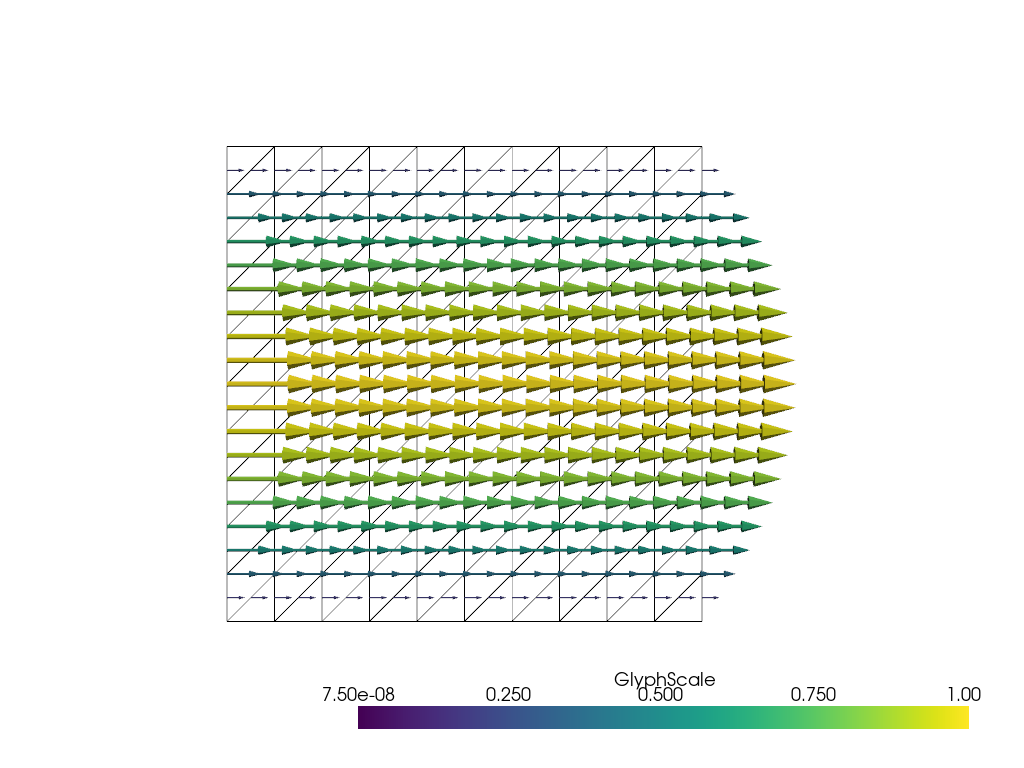

In [8]:
topology, cell_types, geometry = vtk_mesh(V)
values = np.zeros((geometry.shape[0], 3), dtype=np.float64)
values[:, : len(u_n)] = u_n.x.array.real.reshape((geometry.shape[0], len(u_n)))

# Create a point cloud of glyphs
function_grid = pv.UnstructuredGrid(topology, cell_types, geometry)
function_grid["u"] = values
glyphs = function_grid.glyph(orient="u", factor=0.2)

# Create a pv-grid for the mesh
tdim = mesh.topology.dim
mesh.topology.create_connectivity(tdim, tdim)
grid = pv.UnstructuredGrid(*vtk_mesh(mesh, tdim))

# Create plotter
plotter = pv.Plotter()
plotter.add_mesh(grid, style="wireframe", color="k")
plotter.add_mesh(glyphs)
plotter.view_xy()

if not pv.OFF_SCREEN:
    plotter.show()
else:
    fig_as_array = plotter.screenshot("glyphs.png")